In [150]:
import pandas as pd 
customers_cleaned = pd.read_csv("cleaned_supplyguard_data/customers_cleaned.csv")
shipments_cleaned = pd.read_csv("cleaned_supplyguard_data/shipments_cleaned.csv")
deliveries_cleaned = pd.read_csv("cleaned_supplyguard_data/deliveries_cleaned.csv")
drivers_cleaned = pd.read_csv("cleaned_supplyguard_data/drivers_cleaned.csv")
exchange_rates_cleaned = pd.read_csv("cleaned_supplyguard_data/exchange_rates_cleaned.csv")
vehicles_cleaned = pd.read_csv("cleaned_supplyguard_data/vehicles_cleaned.csv")
warehouses_cleaned = pd.read_csv("cleaned_supplyguard_data/warehouses_cleaned.csv")
delivery_labels_cleaned = pd.read_csv("cleaned_supplyguard_data/delivery_labels_cleaned.csv")

In [159]:
#Merge all datasets 
master = customers_cleaned.merge(shipments_cleaned, on="customer_id", how="left")
master = master.merge(deliveries_cleaned, on="shipment_id", how="left")
master = master.merge(drivers_cleaned, on="driver_id", how= "left")
master = master.merge(vehicles_cleaned, on="vehicle_id", how="left")
master = master.merge(delivery_labels_cleaned, on="delivery_id", how="left")
master = master.merge(warehouses_cleaned, on="warehouse_id", how="left")


In [ ]:
master["late_delivery_flag"] =(master["delivery_duration_hours"] > master["delivery_duration_hours"].quantile(0.75).astype(int))
master["very_long_delivery_flag"] = (master["delivery_distance_km"] > master["delivery_distance_km"].quantile(0.90).astype(int))

#Repeated customer delays 
customer_late_count = (master.groupby("customer_id")["late_delivery_flag"].transform("sum"))
customer_delay_threshold = customer_late_count.quantile(0.90)
master["repeated_customer_delay_flag"] = (customer_late_count >= customer_delay_threshold).astype(int)

# customer_late_count = (master.groupby("customer_id")["late_delivery_flag"].transform("sum"))
# master["repeated_customer_delay_flag"] = (customer_late_count >= 2).astype(int)

#Long delivery duration 
master["long_delivery_duration_flag"] =(master["delivery_duration_hours"] > master["delivery_duration_hours"].quantile(0.90).astype(int))

#High-risk route 
master["route"] = (master["city_x"].astype(str) + "-" + master["city_y"].astype(str))

route_late_rate = (master.groupby("route")["late_delivery_flag"].transform("mean"))
route_threshold = route_late_rate.quantile(0.90)
master ["high_risk_route_flag"] = (route_late_rate > route_threshold).astype(int)

# master["route"] = (master["city_x"].astype(str) + "to" + master["city_y"].astype(str))
# route_late_rate = (master.groupby("route")["late_delivery_flag"].transform("mean"))
# master["high_risk_route_flag"] = (route_late_rate >= route_late_rate.quantile(0.90).astype(int))

#Caculate risk scores 
master["risk_score"] = (master["late_delivery_flag"] * 25 +
                        master["very_long_delivery_flag"] *15 +
                        master["repeated_customer_delay_flag"] * 20 +
                        master["long_delivery_duration_flag"] * 20 +
                        master["high_risk_route_flag"] *20
                        )

#Classify risk based on score 
def classify_risk(score): 
    if score <= 30:
        return "Low Risk"
    elif score <=60:
        return "Medium Risk"
    else: 
        return "High Risk"

master["risk_category"] = master["risk_score"].apply(classify_risk)
master[["risk_score", "risk_category"]].head()


,risk_score,risk_category
0,0,Low Risk
1,25,Low Risk
2,60,Medium Risk
3,0,Low Risk
4,0,Low Risk


In [170]:
master[["late_delivery_flag",
        "very_long_delivery_flag", 
        "repeated_customer_delay_flag" ,
        "long_delivery_duration_flag", 
        "high_risk_route_flag", 
        "risk_score" , 
        "risk_category"
        ]].head(10)

,late_delivery_flag,very_long_delivery_flag,repeated_customer_delay_flag,long_delivery_duration_flag,high_risk_route_flag,risk_score,risk_category
0,False,False,0,False,0,0,Low Risk
1,True,False,0,False,0,25,Low Risk
2,True,True,0,True,0,60,Medium Risk
3,False,False,0,False,0,0,Low Risk
4,False,False,0,False,0,0,Low Risk
5,False,False,0,False,0,0,Low Risk
6,True,False,0,False,0,25,Low Risk
7,True,True,0,True,0,60,Medium Risk
8,False,False,0,False,0,0,Low Risk
9,False,False,0,False,0,0,Low Risk


In [172]:

print("Repeated customer delays:")
print(master["repeated_customer_delay_flag"].value_counts())

print("High Risk Route ")
print(master["high_risk_route_flag"].value_counts())



Repeated customer delays:
repeated_customer_delay_flag
0    857307
1    142701
Name: count, dtype: int64
High Risk Route 
high_risk_route_flag
0    900106
1     99902
Name: count, dtype: int64


In [173]:
#Caculate risk scores 
master["risk_score"] = (master["late_delivery_flag"] * 25 +
                        master["very_long_delivery_flag"] *15 +
                        master["repeated_customer_delay_flag"] * 20 +
                        master["long_delivery_duration_flag"] * 20 +
                        master["high_risk_route_flag"] *20
                        )

In [174]:
#Classify risk based on score 
def classify_risk(score): 
    if score <= 30:
        return "Low Risk"
    elif score <=60:
        return "Medium Risk"
    else: 
        return "High Risk"

In [175]:
master[["late_delivery_flag",
        "very_long_delivery_flag", 
        "repeated_customer_delay_flag" ,
        "long_delivery_duration_flag", 
        "high_risk_route_flag", 
        "risk_score" , 
        "risk_category"
        ]].head(10)

,late_delivery_flag,very_long_delivery_flag,repeated_customer_delay_flag,long_delivery_duration_flag,high_risk_route_flag,risk_score,risk_category
0,False,False,0,False,0,0,Low Risk
1,True,False,0,False,0,25,Low Risk
2,True,True,0,True,0,60,Medium Risk
3,False,False,0,False,0,0,Low Risk
4,False,False,0,False,0,0,Low Risk
5,False,False,0,False,0,0,Low Risk
6,True,False,0,False,0,25,Low Risk
7,True,True,0,True,0,60,Medium Risk
8,False,False,0,False,0,0,Low Risk
9,False,False,0,False,0,0,Low Risk


In [176]:
master["risk_category"].value_counts()

risk_category
Low Risk       840266
Medium Risk    122371
High Risk       37371
Name: count, dtype: int64

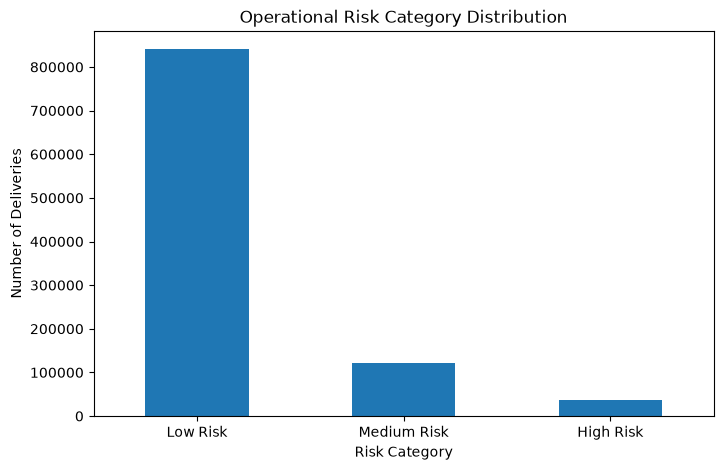

In [177]:
import matplotlib.pyplot as plt 

risk_counts = master["risk_category"].value_counts()
plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")

plt.title("Operational Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=0)

plt.show()